In [14]:
import pandas as pd

# 📥 Load the datasets
X_train_reg = pd.read_csv("X_train_reg.csv")
X_test_reg = pd.read_csv("X_test_reg.csv")
y_train_reg = pd.read_csv("y_train_reg.csv").values.flatten()  # Flatten to 1D array
y_test_reg = pd.read_csv("y_test_reg.csv").values.flatten()    # Flatten to 1D array

# ✅ Verify the shapes
print(f"X_train_reg shape: {X_train_reg.shape}")
print(f"X_test_reg shape: {X_test_reg.shape}")
print(f"y_train_reg shape: {y_train_reg.shape}")
print(f"y_test_reg shape: {y_test_reg.shape}")

# 🔍 Preview
print("\n📊 X_train_reg Preview:")
print(X_train_reg.head())

print("\n📊 y_train_reg Preview:")
print(y_train_reg[:5])


X_train_reg shape: (217811, 28)
X_test_reg shape: (54453, 28)
y_train_reg shape: (217811,)
y_test_reg shape: (54453,)

📊 X_train_reg Preview:
                  Date  Year  Month  Day  Hour  DayOfWeek Primary Type  \
0  2014-07-15 10:20:00  2014      7   15    10          1     GAMBLING   
1  2005-12-08 08:32:00  2005     12    8     8          3     BURGLARY   
2  2001-01-09 19:25:00  2001      1    9    19          1    NARCOTICS   
3  2011-07-06 17:13:00  2011      7    6    17          2      ASSAULT   
4  2002-12-26 19:00:00  2002     12   26    19          3        THEFT   

   District  Community Area  Ward  ...  Hour_sin  Hour_cos  Crime_MA_7D  \
0        17              13    40  ...  0.500000 -0.866025     0.543476   
1        12              28     2  ...  0.866025 -0.500000     0.691120   
2         5              23    37  ... -0.965926  0.258819     0.582578   
3         2              35     3  ... -0.965926 -0.258819     0.685829   
4        18               8    27  ...

In [15]:
from sklearn.preprocessing import MinMaxScaler

# 🚀 Initialize the scaler
target_scaler = MinMaxScaler()

# 🛠️ Reshape for scaling
y_train_reg_scaled = target_scaler.fit_transform(y_train_reg.reshape(-1, 1)).flatten()
y_test_reg_scaled = target_scaler.transform(y_test_reg.reshape(-1, 1)).flatten()

# ✅ Verify the scaling
print("\n📊 Y_train_reg_scaled Range:")
print(f"Min: {y_train_reg_scaled.min()}")
print(f"Max: {y_train_reg_scaled.max()}")

print("\n📊 Y_test_reg_scaled Range:")
print(f"Min: {y_test_reg_scaled.min()}")
print(f"Max: {y_test_reg_scaled.max()}")



📊 Y_train_reg_scaled Range:
Min: 0.0
Max: 0.9999999999999999

📊 Y_test_reg_scaled Range:
Min: 0.00267379679144385
Max: 0.997994652406417


In [16]:
import joblib

# 💾 Save the scaler to a file
scaler_filename = "target_scaler.pkl"
joblib.dump(target_scaler, scaler_filename)

print("\n✅ Target scaler saved successfully!")



✅ Target scaler saved successfully!


In [17]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 🌟 LightGBM parameters
params = {
    'objective': 'regression',           # Regression task
    'metric': 'rmse',                     # Use RMSE as the metric
    'boosting_type': 'gbdt',              # Gradient Boosting Decision Tree
    'n_estimators': 1000,                 # Number of boosting rounds
    'learning_rate': 0.1,                  # Step size shrinkage
    'max_depth': 10,                      # Maximum tree depth
    'num_leaves': 31,                     # Number of leaves in each tree
    'min_data_in_leaf': 20,               # Minimum data per leaf to avoid overfitting
    'feature_fraction': 0.8,              # Randomly select 80% of features per tree
    'bagging_fraction': 0.8,              # Randomly select 80% of data per tree
    'bagging_freq': 5,                    # Perform bagging every 5 iterations
    'verbose': -1,                         # Suppress logs
    'random_state': 42                     # Ensure reproducibility
}

In [21]:
# 🛠️ Drop unnecessary object columns
X_train_reg_lgb = X_train_reg.drop(['Date', 'Primary Type'], axis=1)
X_test_reg_lgb = X_test_reg.drop(['Date', 'Primary Type'], axis=1)

print("\n✅ Categorical columns removed!")
print(f"X_train_reg_lgb shape: {X_train_reg_lgb.shape}")
print(f"X_test_reg_lgb shape: {X_test_reg_lgb.shape}")

# 🎯 Create new LightGBM Datasets with the cleaned data
train_data_lgb = lgb.Dataset(X_train_reg_lgb, label=y_train_reg_scaled)
test_data_lgb = lgb.Dataset(X_test_reg_lgb, label=y_test_reg_scaled)

# 🚀 Train the LightGBM model
print("\n✅ Training LightGBM...")

model = lgb.train(
    params,
    train_data_lgb,
    valid_sets=[train_data_lgb, test_data_lgb],
    valid_names=['Train', 'Test'],
    callbacks=[
        lgb.early_stopping(50),          # Stop if no improvement after 50 rounds
        lgb.log_evaluation(100)          # Log evaluation every 100 rounds
    ]
)

print("\n✅ Model training complete!")



✅ Categorical columns removed!
X_train_reg_lgb shape: (217811, 26)
X_test_reg_lgb shape: (54453, 26)

✅ Training LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	Train's rmse: 0.0067799	Test's rmse: 0.00680263
[200]	Train's rmse: 0.00562066	Test's rmse: 0.0056717
[300]	Train's rmse: 0.0049012	Test's rmse: 0.00496134
[400]	Train's rmse: 0.0043553	Test's rmse: 0.00442451
[500]	Train's rmse: 0.00392258	Test's rmse: 0.00400091
[600]	Train's rmse: 0.00363712	Test's rmse: 0.00372132
[700]	Train's rmse: 0.00338996	Test's rmse: 0.00348719
[800]	Train's rmse: 0.00318114	Test's rmse: 0.00328765
[900]	Train's rmse: 0.00300875	Test's rmse: 0.00311801
[1000]	Train's rmse: 0.00285163	Test's rmse: 0.00296956
Did not meet early stopping. Best iteration is:
[1000]	Train's rmse: 0.00285163	Test's rmse: 0.00296956

✅ Model training complete!


In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ✅ Make predictions on train and test sets
y_train_pred_scaled = model.predict(X_train_reg_lgb)
y_test_pred_scaled = model.predict(X_test_reg_lgb)

# ✅ Inverse transform the predictions to the original scale
y_train_pred = target_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
y_test_pred = target_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

# ✅ Calculate the metrics
train_mae = mean_absolute_error(y_train_reg, y_train_pred)
test_mae = mean_absolute_error(y_test_reg, y_test_pred)

train_mse = mean_squared_error(y_train_reg, y_train_pred)
test_mse = mean_squared_error(y_test_reg, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train_reg, y_train_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)

# ✅ Display the results
print("\n🔥 **Model Performance Metrics:**")
print(f"📊 Train Set:")
print(f"   - MAE: {train_mae:.4f}")
print(f"   - MSE: {train_mse:.4f}")
print(f"   - RMSE: {train_rmse:.4f}")
print(f"   - R² Score: {train_r2:.4f}")

print(f"\n📊 Test Set:")
print(f"   - MAE: {test_mae:.4f}")
print(f"   - MSE: {test_mse:.4f}")
print(f"   - RMSE: {test_rmse:.4f}")
print(f"   - R² Score: {test_r2:.4f}")



🔥 **Model Performance Metrics:**
📊 Train Set:
   - MAE: 3.3661
   - MSE: 18.1991
   - RMSE: 4.2660
   - R² Score: 0.9997

📊 Test Set:
   - MAE: 3.5038
   - MSE: 19.7354
   - RMSE: 4.4425
   - R² Score: 0.9997


In [23]:
import pandas as pd

# ✅ Create a DataFrame for better visualization
sample_df = pd.DataFrame({
    "Actual": y_test_reg[:20],           # First 20 true values
    "Predicted": y_test_pred[:20],       # First 20 predicted values
    "Difference": y_test_reg[:20] - y_test_pred[:20]  # Difference
})

# ✅ Display the sample predictions
print("\n🔍 **Sample Predictions vs. Actual Values:**")
print(sample_df)



🔍 **Sample Predictions vs. Actual Values:**
    Actual    Predicted  Difference
0    956.0   956.103979   -0.103979
1   1039.0  1040.178466   -1.178466
2   1177.0  1175.678509    1.321491
3   1424.0  1423.679338    0.320662
4   1385.0  1385.327164   -0.327164
5   1065.0  1067.822885   -2.822885
6   1409.0  1410.266015   -1.266015
7    743.0   742.022298    0.977702
8    846.0   841.928197    4.071803
9   1100.0  1104.571830   -4.571830
10  1161.0  1153.215304    7.784696
11   752.0   764.083896  -12.083896
12   930.0   927.088135    2.911865
13  1452.0  1442.673483    9.326517
14  1204.0  1201.422474    2.577526
15  1220.0  1221.077359   -1.077359
16  1362.0  1358.205682    3.794318
17   813.0   809.445764    3.554236
18  1398.0  1392.632033    5.367967
19  1313.0  1321.608565   -8.608565


C:\Users\atuly\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


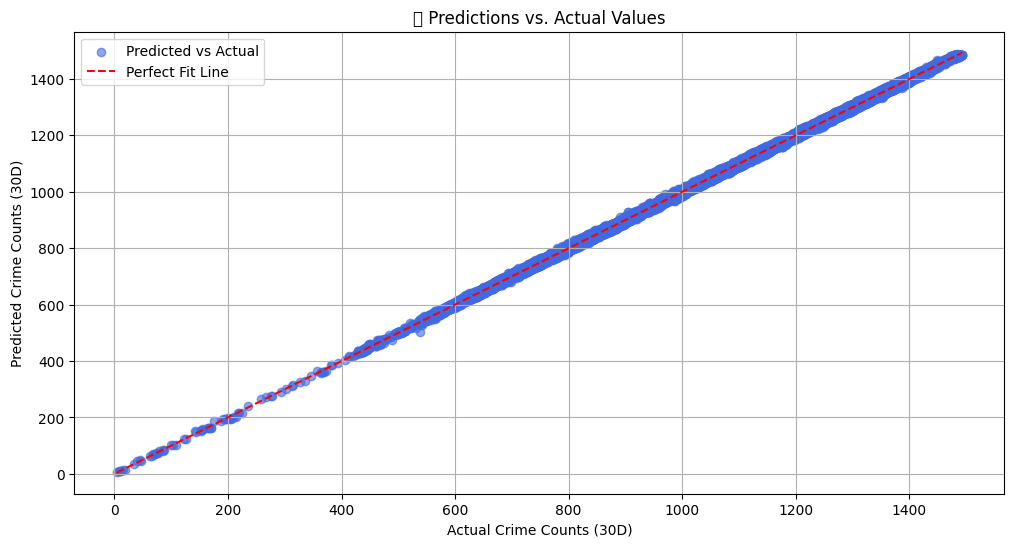

In [24]:
import matplotlib.pyplot as plt

# ✅ Scatter Plot
plt.figure(figsize=(12, 6))
plt.scatter(y_test_reg, y_test_pred, color='royalblue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', label='Perfect Fit Line')
plt.xlabel("Actual Crime Counts (30D)")
plt.ylabel("Predicted Crime Counts (30D)")
plt.title("📊 Predictions vs. Actual Values")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\atuly\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


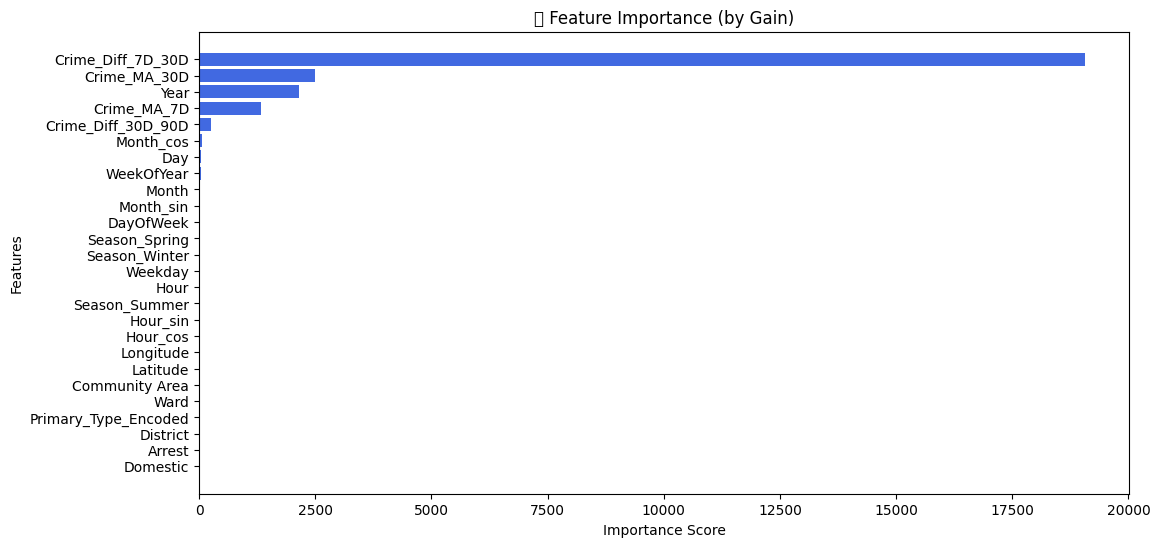

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# 📊 Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_reg_lgb.columns,
    'Importance': model.feature_importance(importance_type='gain')  # 'gain' measures how much each feature contributes to the model
})

# 📉 Sort by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# 🎯 Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='royalblue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('🔥 Feature Importance (by Gain)')
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()


In [30]:
import joblib

# ✅ Define model save path
model_path = "lightgbm_regression_model.pkl"

# 💾 Save the LightGBM model as .pkl
joblib.dump(model, model_path)
print(f"✅ Model saved successfully at: {model_path}")


✅ Model saved successfully at: lightgbm_regression_model.pkl
